These codes:
- Load image paths
- Count tumor and nontumor images
- Display sample images
- Check image sizes
- Check grayscale pixel values

In [1]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
PROJECT_DIR = Path.cwd().parent
DATASET_PATH = PROJECT_DIR / "data" / "brain_tumor_dataset"

print("Project directory:", PROJECT_DIR)
print("Dataset path:", DATASET_PATH)
print("Dataset exists:", DATASET_PATH.exists())
print("Yes folder exists:", (DATASET_PATH / "yes").exists())
print("No folder exists:", (DATASET_PATH / "no").exists())

Project directory: C:\Users\elifn\DSAI 583\PROJECT
Dataset path: C:\Users\elifn\DSAI 583\PROJECT\data\brain_tumor_dataset
Dataset exists: True
Yes folder exists: True
No folder exists: True


In [3]:
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

yes_paths = [
    path for path in (DATASET_PATH / "yes").iterdir()
    if path.suffix.lower() in valid_extensions
]

no_paths = [
    path for path in (DATASET_PATH / "no").iterdir()
    if path.suffix.lower() in valid_extensions
]

print("Tumor images:", len(yes_paths))
print("No tumor images:", len(no_paths))
print("Total images:", len(yes_paths) + len(no_paths))

Tumor images: 155
No tumor images: 98
Total images: 253


In [4]:
data = []

for path in yes_paths:
    data.append({
        "path": path,
        "label": 1,
        "class_name": "tumor"
    })

for path in no_paths:
    data.append({
        "path": path,
        "label": 0,
        "class_name": "no_tumor"
    })

df = pd.DataFrame(data)

In [5]:
df.head()

,path,label,class_name
0,C:\Users\elifn\DSAI 583\PROJECT\data\brain_tum...,1,tumor
1,C:\Users\elifn\DSAI 583\PROJECT\data\brain_tum...,1,tumor
2,C:\Users\elifn\DSAI 583\PROJECT\data\brain_tum...,1,tumor
3,C:\Users\elifn\DSAI 583\PROJECT\data\brain_tum...,1,tumor
4,C:\Users\elifn\DSAI 583\PROJECT\data\brain_tum...,1,tumor


In [6]:
df.tail()

,path,label,class_name
248,C:\Users\elifn\DSAI 583\PROJECT\data\brain_tum...,0,no_tumor
249,C:\Users\elifn\DSAI 583\PROJECT\data\brain_tum...,0,no_tumor
250,C:\Users\elifn\DSAI 583\PROJECT\data\brain_tum...,0,no_tumor
251,C:\Users\elifn\DSAI 583\PROJECT\data\brain_tum...,0,no_tumor
252,C:\Users\elifn\DSAI 583\PROJECT\data\brain_tum...,0,no_tumor


In [7]:
df["class_name"].value_counts()

class_name
tumor       155
no_tumor     98
Name: count, dtype: int64

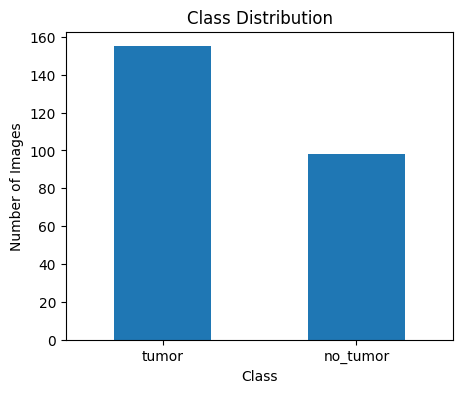

In [8]:
plt.figure(figsize=(5, 4))
df["class_name"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.show()

In [9]:
# for one image only

sample_path = df.iloc[0]["path"]

img = cv2.imread(str(sample_path), cv2.IMREAD_GRAYSCALE)

print("Image path:", sample_path)
print("Image type:", type(img))
print("Image shape:", img.shape)
print("Minimum pixel value:", img.min())
print("Maximum pixel value:", img.max())

Image path: C:\Users\elifn\DSAI 583\PROJECT\data\brain_tumor_dataset\yes\Y1.jpg
Image type: <class 'numpy.ndarray'>
Image shape: (218, 180)
Minimum pixel value: 0
Maximum pixel value: 255


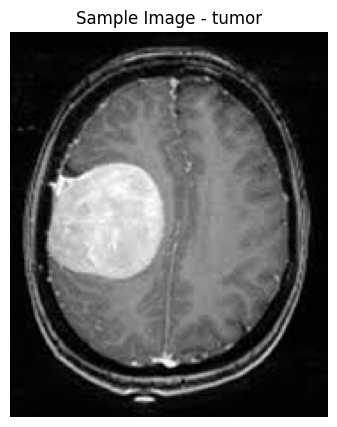

In [10]:
plt.figure(figsize=(5, 5))
plt.imshow(img, cmap="gray")
plt.title(f"Sample Image - {df.iloc[0]['class_name']}")
plt.axis("off")
plt.show()

In [11]:
def show_samples(df, class_name, n=5):
    samples = df[df["class_name"] == class_name].sample(n=n, random_state=42)

    plt.figure(figsize=(15, 4))

    for i, (_, row) in enumerate(samples.iterrows()):
        img = cv2.imread(str(row["path"]), cv2.IMREAD_GRAYSCALE)

        plt.subplot(1, n, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(class_name)
        plt.axis("off")

    plt.show()

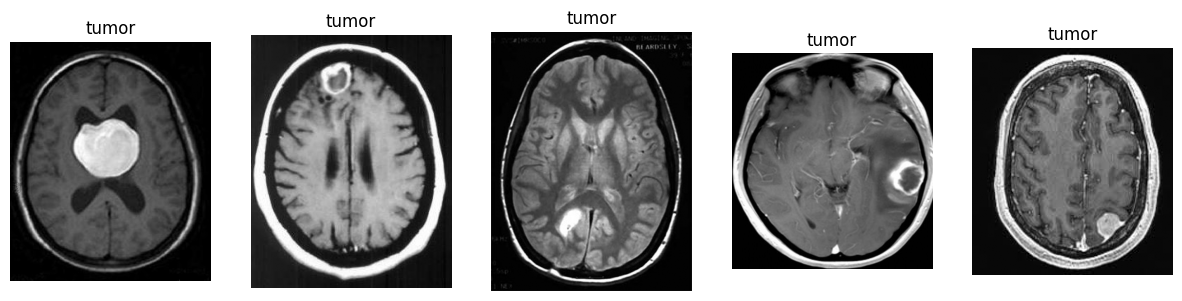

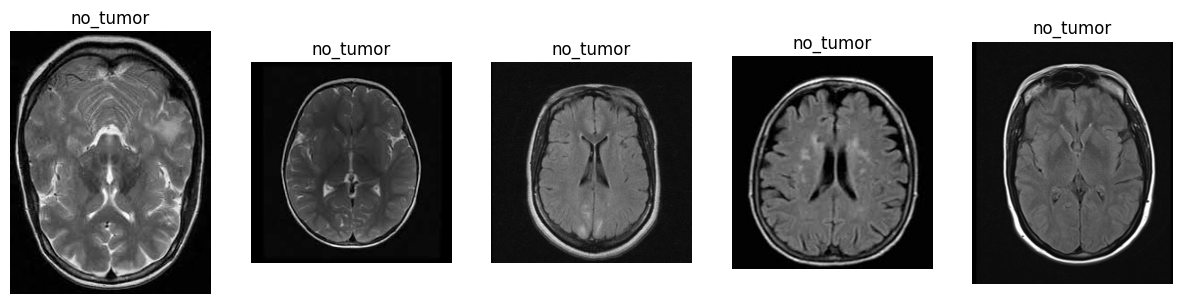

In [12]:
show_samples(df, "tumor", n=5)
show_samples(df, "no_tumor", n=5)

In [13]:
image_shapes = []

for path in df["path"]:
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    image_shapes.append(img.shape)

df["height"] = [shape[0] for shape in image_shapes]
df["width"] = [shape[1] for shape in image_shapes]

df[["height", "width"]].head()

,height,width
0,218,180
1,360,319
2,348,287
3,336,300
4,630,587


In [14]:
unique_shapes = df[["height", "width"]].drop_duplicates()

print("Number of unique image sizes:", len(unique_shapes))
unique_shapes.head(10)

Number of unique image sizes: 184


,height,width
0,218,180
1,360,319
2,348,287
3,336,300
4,630,587
5,993,825
6,890,700
7,246,205
8,253,200
9,512,512


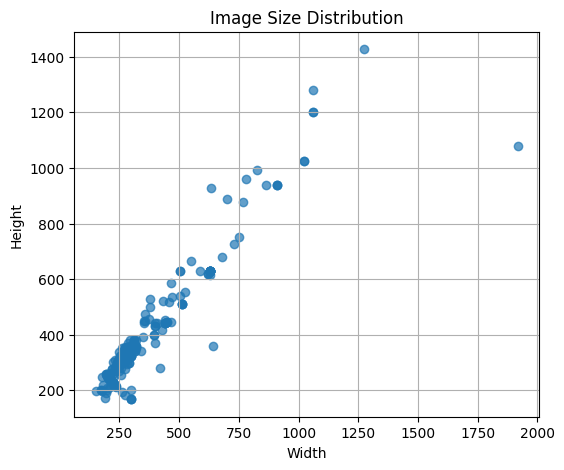

In [15]:
plt.figure(figsize=(6, 5))
plt.scatter(df["width"], df["height"], alpha=0.7)
plt.title("Image Size Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.grid(True)
plt.show()

In [16]:
pixel_stats = []

for path in df["path"]:
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    pixel_stats.append({
        "min": img.min(),
        "max": img.max(),
        "mean": img.mean(),
        "std": img.std()
    })

pixel_df = pd.DataFrame(pixel_stats)

pixel_df.describe()

,min,max,mean,std
count,253.000000,253.000000,253.000000,253.000000
mean,1.031621,250.952569,63.348286,56.073105
std,3.961996,13.222070,23.041698,12.246970
min,0.000000,139.000000,18.232738,30.103807
25%,0.000000,255.000000,46.699336,47.240686
50%,0.000000,255.000000,58.213645,55.884495
75%,0.000000,255.000000,75.591358,64.204306
max,33.000000,255.000000,161.198867,101.770466


Pixel values are in the range 0–255 and below confirms that the images are standard grayscale images. Later, I will normalize to [0,1].

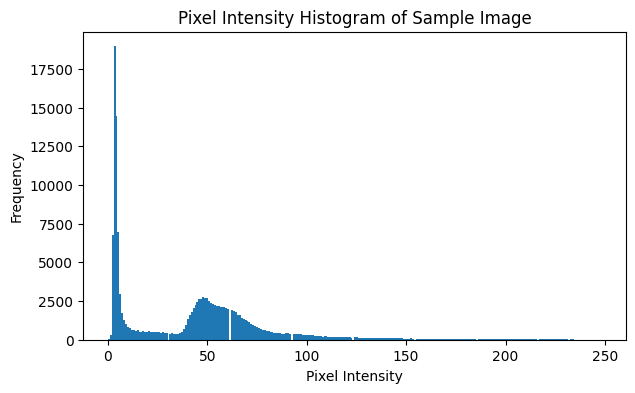

In [17]:
plt.figure(figsize=(7, 4))
plt.hist(img.ravel(), bins=256)
plt.title("Pixel Intensity Histogram of Sample Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

GHE and CLAHE work by changing intensity distributions to improve contrast, that's why i checked the pixel instensity.

In [18]:
bad_files = []

for path in df["path"]:
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)

    if img is None:
        bad_files.append(path)

print("Number of unreadable images:", len(bad_files))

bad_files

Number of unreadable images: 0


[]